# Оценка модели

In [1]:
!pip install -q datasets peft
!pip install transformers==4.30.0 -q
!pip install bert-score==0.3.13 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 12.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00


In [2]:
import bert_score
import transformers
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

torch.cuda.empty_cache()
import gc
gc.collect()

60

In [4]:
BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"
ADAPTER_PATH = "/content/drive/MyDrive/qwen_coding_3b_model"

from google.colab import drive
drive.mount('/content/drive')

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True
)

try:
    model = PeftModel.from_pretrained(model, ADAPTER_PATH)
except Exception as e:
    model = PeftModel.from_pretrained(
        model,
        ADAPTER_PATH,
        is_trainable=False
    )

model.eval()
torch.cuda.empty_cache()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Загрузка тестовых данных

In [5]:
test_df = pd.read_csv('test_data.csv')

test_prompts = []
test_targets = []

for idx, row in test_df.iterrows():
    full_text = row['text']
    parts = full_text.split('<|im_start|>assistant\n')
    if len(parts) > 1:
        test_prompts.append(parts[0] + '<|im_start|>assistant\n')
        test_targets.append(parts[1].replace('<|im_end|>', '').strip())


print("\nПример тестовых данных:\n")
print(f"Промпт :\n{test_prompts[0][:200]}...")
print("\nЦелевой ответ:\n")
print(test_targets[0][:200] + "...")


Пример тестовых данных:

Промпт :
<|im_start|>system
Ты — эксперт по анализу интервью. Твоя задача — выделить в тексте интервью тематические коды и разметить его.

Ты обязан строго соблюдать формат:
- Каждая строка: "цитата" - **Назва...

Целевой ответ:

**Общий код 1: Переход к самостоятельности: материнство как точка взросления (синхронический сдвиг)**
"Наверное, самым главным это... То, как я познакомилась с мужем, то, как он мне сделал предложение...


Функции генерации с разными стратегиями

In [6]:
def clear_cuda_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        gc.collect()

def generate_greedy(prompt, max_new_tokens=512):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1800).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated

def generate_beam_search(prompt, max_new_tokens=512, num_beams=5):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1800).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
            do_sample=False,
            length_penalty=1.0,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated

def generate_without_repetition(prompt, max_new_tokens=512):
    clear_cuda_cache()
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1800).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=5,
            early_stopping=True,
            do_sample=False,
            repetition_penalty=1.5,
            no_repeat_ngram_size=4,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    lines = generated.strip().split('\n')
    seen = set()
    unique_lines = []

    for line in lines:
        if not line.strip():
            continue
        key = line[:50]
        if key not in seen:
            seen.add(key)
            unique_lines.append(line)
        else:
            break

    clear_cuda_cache()
    return '\n'.join(unique_lines[:15])

Оценка качества через Bertscore

In [7]:
import torch
from bert_score import BERTScorer

bertscorer = BERTScorer(
    model_type="bert-base-multilingual-cased",
    lang="ru",
    rescale_with_baseline=False,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

def compute_bertscore(predictions, references):
    P, R, F1 = bertscorer.score(predictions, references)

    f1_mean = float(F1.mean().cpu().item())
    p_mean = float(P.mean().cpu().item())
    r_mean = float(R.mean().cpu().item())

    return f1_mean, p_mean, r_mean

print("Тест BERTScore:")
test_pred = ["Это хороший код для анализа интервью"]
test_ref = ["Это отличный код для анализа интервью"]

f1, p, r = compute_bertscore(test_pred, test_ref)
print(f"  F1: {f1:.4f}, Precision: {p:.4f}, Recall: {r:.4f}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Тест BERTScore:
  F1: 0.9230, Precision: 0.9278, Recall: 0.9182


Экспеертная оценка через LLM

In [8]:
import openai
import time
from typing import Tuple, Dict, Any
import re

USE_LLM_REWARD = True
OPENROUTER_API_KEY = "ключ скрыт"
JUDGE_MODEL = "openai/gpt-oss-120b:free"
LLM_MAX_RETRIES = 5
LLM_BASE_DELAY = 1.0

if USE_LLM_REWARD:
    openrouter_client = openai.OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY
    )
    print("OpenRouter клиент инициализирован")
else:
    openrouter_client = None

def call_llm_judge(prompt: str, max_retries: int = LLM_MAX_RETRIES) -> Dict[str, float]:
    """
    Вызов LLM-судьи через OpenRouter API
    """
    for attempt in range(max_retries):
        try:
            response = openrouter_client.chat.completions.create(
                model=JUDGE_MODEL,
                messages=[
                    {"role": "system", "content": "Ты — эксперт по анализу интервью и качественному кодированию. Отвечай ТОЛЬКО числами в формате X,Y,Z без лишнего текста."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.1,
                max_tokens=50,
                extra_headers={
                    "HTTP-Referer": "https://colab.research.google.com",
                    "X-Title": "Interview Coding Evaluation"
                }
            )

            answer = response.choices[0].message.content.strip()


            numbers = re.findall(r'(\d+(?:\.\d+)?)', answer)
            if len(numbers) >= 3:
                scores = {
                    "relevancy": float(numbers[0]),
                    "coherence": float(numbers[1]),
                    "insight": float(numbers[2])
                }
                for key in scores:
                    scores[key] = max(1.0, min(5.0, scores[key]))
                return scores
            else:
                if ',' in answer:
                    parts = answer.split(',')
                    if len(parts) >= 3:
                        return {
                            "relevancy": float(parts[0].strip()),
                            "coherence": float(parts[1].strip()),
                            "insight": float(parts[2].strip())
                        }
                raise ValueError(f"Не удалось распарсить ответ: {answer}")

        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(LLM_BASE_DELAY * (2 ** attempt))

    return {"relevancy": 3.0, "coherence": 3.0, "insight": 3.0}


def create_evaluation_prompt(generated_coding: str, reference_coding: str, topic: str = "") -> str:
    """
    Создание промпта для LLM-судьи
    """
    max_len = 800
    gen_trunc = generated_coding[:max_len] + "..." if len(generated_coding) > max_len else generated_coding
    ref_trunc = reference_coding[:max_len] + "..." if len(reference_coding) > max_len else reference_coding

    prompt = f"""Оцени качество кодирования интервью по шкале 1-5 (1=плохо, 5=отлично).

Тема: {topic}

ЭТАЛОН (референс):
{ref_trunc}

ПРЕДСКАЗАНИЕ МОДЕЛИ:
{gen_trunc}

Оцени по трём параметрам:
1. Релевантность - насколько коды соответствуют содержанию интервью
2. Когерентность - грамматическая корректность и стилистическая приемлемость
3. Теоретический инсайт - глубина и концептуальная ценность кодов

ОТВЕТЬ ТОЛЬКО ТРЕМЯ ЧИСЛАМИ через запятую в формате: relevancy,coherence,insight
Пример: 4.5,4.0,3.5"""

    return prompt


def evaluate_coding_quality(generated_coding: str, reference_coding: str, topic: str = "") -> Tuple[float, float, float]:
    """
    Оценка качества кодирования

    Returns:
        (relevancy, coherence, insight) - оценки от 1 до 5
    """
    if not generated_coding or len(generated_coding) < 50:
        return 2.0, 2.0, 1.5

    if USE_LLM_REWARD:
        prompt = create_evaluation_prompt(generated_coding, reference_coding, topic)
        scores = call_llm_judge(prompt)
        return scores["relevancy"], scores["coherence"], scores["insight"]


# Тест LLM-оценщика
print("\n ТЕСТ LLM-ОЦЕНЩИКА")

test_pred = """**Общий код 1: Мотивация и атмосфера в коллективе**
"Мне нравится моя работа" - **Положительное отношение (конкретный код)**
"У нас отличный коллектив" - **Значимость коллектива (конкретный код)**"""

test_ref = """**Общий код 1: Отношение к работе**
"Мне очень нравится моя работа" - **Позитивное отношение (конкретный код)**
"У нас отличный коллектив, всегда можно обратиться за помощью" - **Важность коллектива (конкретный код)**"""

print("Оценка качества кодирования:")
rel, coh, ins = evaluate_coding_quality(test_pred, test_ref, "Поколение Z в поисках баланса")
print(f"  Релевантность: {rel:.2f}/5")
print(f"  Когерентность: {coh:.2f}/5")
print(f"  Инсайт: {ins:.2f}/5")
print(f"  Среднее: {(rel+coh+ins)/3:.2f}/5")

OpenRouter клиент инициализирован

 ТЕСТ LLM-ОЦЕНЩИКА
Оценка качества кодирования:
  Релевантность: 4.00/5
  Когерентность: 4.00/5
  Инсайт: 3.50/5
  Среднее: 3.83/5


Общая функция оценки модели

In [13]:
def evaluate_model_on_test(strategy="without_repetition", num_samples=None):
    if num_samples is None:
        num_samples = len(test_prompts)

    num_samples = min(num_samples, len(test_prompts))
    indices = np.random.choice(len(test_prompts), num_samples, replace=False)

    predictions = []
    references = []

    print(f"Стратегия: {strategy.upper()}")
    print(f"Выборка: {num_samples}")

    for i, idx in enumerate(indices):
        prompt = test_prompts[idx]
        target = test_targets[idx]

        clear_cuda_cache()

        if strategy == "greedy":
            generated = generate_greedy(prompt)
        else:
            generated = generate_without_repetition(prompt)

        predictions.append(generated)
        references.append(target)
        print(f"  {i+1}/{num_samples} | Length: {len(generated)}")

    f1, precision, recall = compute_bertscore(predictions, references)
    print(f"  BERTScore F1: {f1:.4f}")

    llm_scores = []

    for i in range(num_samples):
        rel, coh, ins = evaluate_coding_quality(
            predictions[i],
            references[i],
            topic="Interview analysis"
        )
        avg_score = (rel + coh + ins) / 3
        llm_scores.append(avg_score)
        print(f"  {i+1}/{num_samples}: {avg_score:.2f}/5")

        if i < num_samples - 1:
            time.sleep(0.5)

    llm_avg = np.mean(llm_scores)
    combined_score = (f1 + llm_avg / 5) / 2

    results = {
        "strategy": strategy,
        "num_samples": num_samples,
        "bert_score_f1": f1,
        "bert_score_precision": precision,
        "bert_score_recall": recall,
        "llm_score": llm_avg,
        "combined_score": combined_score
    }

    print(f"\nRESULTS:")
    print(f"  BERTScore F1: {f1:.4f}")
    print(f"  LLM Score:    {llm_avg:.2f}/5")
    print(f"  Combined:     {combined_score:.4f}")

    return results, predictions, references

Сравнение генераций

In [42]:
def clear_cuda_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        gc.collect()

strategies = ["greedy", "beam_search", "without_repetition"]
comparison_results = []

for strategy in strategies:
    clear_cuda_cache()
    results, _, _ = evaluate_model_on_test(
        strategy=strategy,
        num_samples=3
    )
    comparison_results.append(results)
    print("\n" + "-"*40)

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df[['strategy', 'bert_score_f1', 'llm_score', 'combined_score']].to_string(index=False))

if len(comparison_df) > 0:
    best_combined = comparison_df.loc[comparison_df['combined_score'].idxmax(), 'strategy']
    print(f"\nЛучшая стратегия: {best_combined.upper()}")

Стратегия: GREEDY
Выборка: 3
  1/3 | Length: 1524
  2/3 | Length: 1653
  3/3 | Length: 1564
  BERTScore F1: 0.6771
  1/3: 3.67/5
  2/3: 3.67/5
  3/3: 4.00/5

RESULTS:
  BERTScore F1: 0.6771
  LLM Score:    3.78/5
  Combined:     0.7163

----------------------------------------
Стратегия: BEAM_SEARCH
Выборка: 3
  1/3 | Length: 1579
  2/3 | Length: 1624
  3/3 | Length: 1508
  BERTScore F1: 0.7176
  1/3: 3.67/5
  2/3: 4.00/5
  3/3: 3.67/5

RESULTS:
  BERTScore F1: 0.7176
  LLM Score:    3.78/5
  Combined:     0.7366

----------------------------------------
Стратегия: WITHOUT_REPETITION
Выборка: 3
  1/3 | Length: 1580
  2/3 | Length: 1417
  3/3 | Length: 1573
  BERTScore F1: 0.7198
  1/3: 4.00/5
  2/3: 2.00/5
  3/3: 3.67/5

RESULTS:
  BERTScore F1: 0.7198
  LLM Score:    3.22/5
  Combined:     0.6821

----------------------------------------
          strategy  bert_score_f1  llm_score  combined_score
            greedy       0.677111   3.777778        0.716333
       beam_search       0.

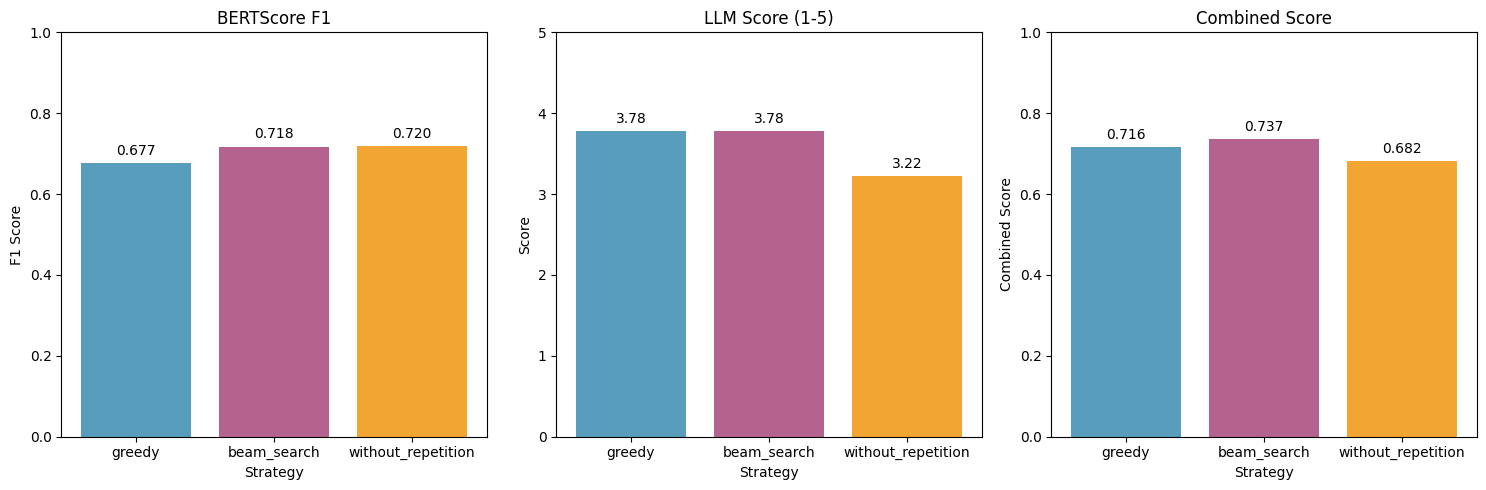

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

strategies = comparison_df['strategy'].tolist()
colors = {'greedy': '#2E86AB', 'beam_search': '#A23B72', 'without_repetition': '#F18F01'}
bar_colors = [colors[s] for s in strategies]

bars1 = axes[0].bar(comparison_df['strategy'], comparison_df['bert_score_f1'],
                    color=bar_colors, alpha=0.8)
axes[0].set_ylim(0, 1)
axes[0].set_title('BERTScore F1')
axes[0].set_ylabel('F1 Score')
axes[0].set_xlabel('Strategy')
for bar, val in zip(bars1, comparison_df['bert_score_f1']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10)

bars2 = axes[1].bar(comparison_df['strategy'], comparison_df['llm_score'],
                    color=bar_colors, alpha=0.8)
axes[1].set_ylim(0, 5)
axes[1].set_title('LLM Score (1-5)')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Strategy')
for bar, val in zip(bars2, comparison_df['llm_score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=10)

bars3 = axes[2].bar(comparison_df['strategy'], comparison_df['combined_score'],
                    color=bar_colors, alpha=0.8)
axes[2].set_ylim(0, 1)
axes[2].set_title('Combined Score')
axes[2].set_ylabel('Combined Score')
axes[2].set_xlabel('Strategy')
for bar, val in zip(bars3, comparison_df['combined_score']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150)
plt.show()

In [46]:
best_strategy = comparison_df.loc[comparison_df['combined_score'].idxmax(), 'strategy']
best_score = comparison_df['combined_score'].max()
best_bert = comparison_df['bert_score_f1'].max()
best_llm = comparison_df['llm_score'].max()

print(f"\nBest strategy: {best_strategy.upper()}")
print(f"   Combined Score: {best_score:.4f}")
print(f"   BERTScore F1:   {best_bert:.4f}")
print(f"   LLM Score:      {best_llm:.2f}/5")


Best strategy: BEAM_SEARCH
   Combined Score: 0.7366
   BERTScore F1:   0.7198
   LLM Score:      3.78/5


Работа модели с лучшей стратегией

In [47]:
test_prompt = test_prompts[0]
test_target = test_targets[0]

print(f"\nГенерация с {best_combined.upper()}")

if best_combined == "greedy":
    generated = generate_greedy(test_prompt)
elif best_combined == "beam_search":
    generated = generate_beam_search(test_prompt)
else:
    generated = generate_without_repetition(test_prompt)

print('\nСгенерированный результат:')
print(generated)

print("\nТаргет:")
print(test_target)

f1, _, _ = compute_bertscore([generated], [test_target])
print(f"\nBERTScore: {f1:.4f}")

torch.cuda.empty_cache()
gc.collect()


Генерация с BEAM_SEARCH

Сгенерированный результат:
**Общий код 1: Переход к самостоятельной жизни и ответственность (синхронический сдвиг)**
"Сложные выборы... Ой! (смеется) Я даже не могу предположить сложные выборы. (пауза) Сложно мне, наверное, давалось каждый раз из-за того, что у нас всё-таки с работой не очень в [название города]. Каждый раз мне сложно, так я несколько работ поменяла, каждый раз мне сложно давалось, чтобы вот лучше мне как бы то, что более будет... скажем так, по душе более спокойно, то, что мне больше будет нравиться, нежели чем я буду ездить куда-то. Ну, я ездила, наверное, на [название предприятия]." - **Выбор в пользу простоты (конкретный код)**
"Сложные выборы... Ой! (смеется) Я даже не могу предположить сложные выборы. (пауза) Сложно мне, наверное, давалось каждый раз из-за того, что у нас всё-таки с работой не очень в [название города]. Каждый раз мне сложно, так я несколько работ поменяла, каждый раз мне сложно давалось, чтобы вот лучше мне как бы то, ч

21452

Работа модели с генерацией без повторений

In [48]:
test_prompt = test_prompts[0]
test_target = test_targets[0]

generated = generate_without_repetition(test_prompt)

print('\nСгенерированный результат:')
print(generated)

print("\nТаргет:")
print(test_target)

f1, _, _ = compute_bertscore([generated], [test_target])
print(f"\nBERTScore: {f1:.4f}")

torch.cuda.empty_cache()
gc.collect()


Сгенерированный результат:
**Объективно-постфактумный анализ жизненных событий и их влияние на личностное развитие (общий код 1)**
"Семь ключевых событий в моей жизни - это, конечно, знакомство с будущим мужем, его предложение, пожениться, родить ребенка, как он что-то начал говорить, как он начал ходить." - **Основные жизненные события как ключевые вехи (конктре́тный ко́д)**
"Первые два - знакомство и предложение, это самые важные. Потому что после этого я поняла, что я беременна." - **Самые важные события: знакомство, предложение, беременность (конктере́́́тныйко́́́д)**  
"Потому что до этого мы пытались, но не получалось." - **Отсутствие успеха в попытках ранее (конктера́́́цкийко́д)**
**Смена жизненных приоритетов и становление ответственной личности (конктерно́йко́ды)**
"Какие-то приоритеты изменились. Например, раньше я считала, что главное - это работа. А сейчас я понимаю, что нет, главное - это семья и ребенок." - **Переориентация жизненного приоритета (конктё́рноико́ды)**  
"То

0